# Airline Delay Cause Analysis

This notebook analyzes airline delay causes using machine learning. We'll explore delay patterns, build classification and regression models to predict delay causes and rates.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras import layers, Model

## 2. Load Dataset

Download and load the airline delay dataset from Kaggle.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdelazizel7or/airline-delay-cause")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Heka\.cache\kagglehub\datasets\abdelazizel7or\airline-delay-cause\versions\1


In [3]:
import os

# Set the path to the downloaded dataset
path = "C:/Users/Heka/.cache/kagglehub/datasets/abdelazizel7or/airline-delay-cause/versions/1"
print(os.listdir(path))


['.vscode', 'Airline_Delay_Cause.csv']


## 3. Data Exploration

In [4]:
import pandas as pd

# Load the airline delay dataset
airline = pd.read_csv(f"{path}/Airline_Delay_Cause.csv")

# Display first few rows
airline.head()


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2022,5,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",136.0,7.0,5.95,0.00,...,0.0,1.00,0.0,0.0,255.0,222.0,0.0,4.0,0.0,29.0
1,2022,5,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",91.0,16.0,7.38,0.00,...,0.0,6.09,0.0,0.0,884.0,351.0,0.0,81.0,0.0,452.0
2,2022,5,9E,Endeavor Air Inc.,ACK,"Nantucket, MA: Nantucket Memorial",19.0,2.0,0.13,0.00,...,0.0,0.88,1.0,0.0,138.0,4.0,0.0,106.0,0.0,28.0
3,2022,5,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",88.0,14.0,7.26,0.76,...,0.0,1.64,0.0,0.0,947.0,585.0,35.0,125.0,0.0,202.0
4,2022,5,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",181.0,19.0,13.84,0.00,...,0.0,2.09,0.0,0.0,808.0,662.0,0.0,87.0,0.0,59.0


In [5]:
def describe_dataframe(dataframe):
    """
    Comprehensive function to display dataframe information including:
    - Data types and non-null counts
    - Descriptive statistics
    - Shape and column names
    """
    print("\n DataFrame Info ")
    print(50*"=")
    dataframe.info()

    print("\n Descriptive Statistics ")
    print(50*"=")

    print(dataframe.describe())

    print("\n Shape ")
    print(50*"=")
    print(dataframe.shape)

    print("\n Columns ")
    print(50*"=")

    print(dataframe.columns)


describe_dataframe(airline)


 DataFrame Info 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318017 entries, 0 to 318016
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 318017 non-null  int64  
 1   month                318017 non-null  int64  
 2   carrier              318013 non-null  object 
 3   carrier_name         318013 non-null  object 
 4   airport              318014 non-null  object 
 5   airport_name         318017 non-null  object 
 6   arr_flights          317524 non-null  float64
 7   arr_del15            317285 non-null  float64
 8   carrier_ct           317525 non-null  float64
 9   weather_ct           317523 non-null  float64
 10  nas_ct               317529 non-null  float64
 11  security_ct          317529 non-null  float64
 12  late_aircraft_ct     317529 non-null  float64
 13  arr_cancelled        317529 non-null  float64
 14  arr_diverted         317527 non-null  float64
 15 

In [6]:
# Check for missing values in each column
missing_values = airline.isnull().sum()
missing_values

year                     0
month                    0
carrier                  4
carrier_name             4
airport                  3
airport_name             0
arr_flights            493
arr_del15              732
carrier_ct             492
weather_ct             494
nas_ct                 488
security_ct            488
late_aircraft_ct       488
arr_cancelled          488
arr_diverted           490
arr_delay              494
carrier_delay          492
weather_delay          488
nas_delay              488
security_delay         490
late_aircraft_delay    488
dtype: int64

## 4. Data Cleaning

Remove missing values and unnecessary columns.

In [7]:
# Remove rows with missing values
airline.dropna(inplace=True)


In [8]:
# Drop unnecessary identifier columns (carrier and airport codes)
airline = airline.drop(columns=["carrier", "airport"], errors="ignore")
airline.head()


,year,month,carrier_name,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2022,5,Endeavor Air Inc.,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",136.0,7.0,5.95,0.00,0.05,0.0,1.00,0.0,0.0,255.0,222.0,0.0,4.0,0.0,29.0
1,2022,5,Endeavor Air Inc.,"Albany, GA: Southwest Georgia Regional",91.0,16.0,7.38,0.00,2.54,0.0,6.09,0.0,0.0,884.0,351.0,0.0,81.0,0.0,452.0
2,2022,5,Endeavor Air Inc.,"Nantucket, MA: Nantucket Memorial",19.0,2.0,0.13,0.00,1.00,0.0,0.88,1.0,0.0,138.0,4.0,0.0,106.0,0.0,28.0
3,2022,5,Endeavor Air Inc.,"Alexandria, LA: Alexandria International",88.0,14.0,7.26,0.76,4.35,0.0,1.64,0.0,0.0,947.0,585.0,35.0,125.0,0.0,202.0
4,2022,5,Endeavor Air Inc.,"Augusta, GA: Augusta Regional at Bush Field",181.0,19.0,13.84,0.00,3.07,0.0,2.09,0.0,0.0,808.0,662.0,0.0,87.0,0.0,59.0


In [9]:
# Rename columns to more descriptive and consistent names
rename_dict = {
    "year": "year",
    "month": "month",
    "arr_flights": "total_flights",
    "arr_del15": "delayed_flights_15m",
    "arr_cancelled": "cancelled_flights",
    "arr_diverted": "diverted_flights",

    "arr_delay": "total_delay_minutes",

    "carrier_ct": "carrier_delay_flights",
    "weather_ct": "weather_delay_flights",
    "nas_ct": "nas_delay_flights",
    "security_ct": "security_delay_flights",
    "late_aircraft_ct": "late_aircraft_delay_flights",

    "carrier_delay": "carrier_delay_minutes",
    "weather_delay": "weather_delay_minutes",
    "nas_delay": "nas_delay_minutes",
    "security_delay": "security_delay_minutes",
    "late_aircraft_delay": "late_aircraft_delay_minutes"
}


In [10]:
# Apply column renaming
airline = airline.rename(columns=rename_dict)
airline.head()

,year,month,carrier_name,airport_name,total_flights,delayed_flights_15m,carrier_delay_flights,weather_delay_flights,nas_delay_flights,security_delay_flights,late_aircraft_delay_flights,cancelled_flights,diverted_flights,total_delay_minutes,carrier_delay_minutes,weather_delay_minutes,nas_delay_minutes,security_delay_minutes,late_aircraft_delay_minutes
0,2022,5,Endeavor Air Inc.,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",136.0,7.0,5.95,0.00,0.05,0.0,1.00,0.0,0.0,255.0,222.0,0.0,4.0,0.0,29.0
1,2022,5,Endeavor Air Inc.,"Albany, GA: Southwest Georgia Regional",91.0,16.0,7.38,0.00,2.54,0.0,6.09,0.0,0.0,884.0,351.0,0.0,81.0,0.0,452.0
2,2022,5,Endeavor Air Inc.,"Nantucket, MA: Nantucket Memorial",19.0,2.0,0.13,0.00,1.00,0.0,0.88,1.0,0.0,138.0,4.0,0.0,106.0,0.0,28.0
3,2022,5,Endeavor Air Inc.,"Alexandria, LA: Alexandria International",88.0,14.0,7.26,0.76,4.35,0.0,1.64,0.0,0.0,947.0,585.0,35.0,125.0,0.0,202.0
4,2022,5,Endeavor Air Inc.,"Augusta, GA: Augusta Regional at Bush Field",181.0,19.0,13.84,0.00,3.07,0.0,2.09,0.0,0.0,808.0,662.0,0.0,87.0,0.0,59.0


In [11]:
# Check for duplicate rows in the dataset
print(f"Number of duplicate rows: {airline.duplicated().sum()}")

Number of duplicate rows: 0


In [12]:
# Check cardinality of categorical variables
print(f"Number of unique airport names: {airline['airport_name'].nunique()}")
print(f"Number of unique carrier names: {airline['carrier_name'].nunique()}")

Number of unique airport names: 418
Number of unique carrier names: 33


## 5. Feature Engineering

Create new features to better understand delay patterns.

In [13]:
# Calculate problem rate: proportion of flights with issues (cancelled, diverted, or delayed >15min)
airline["problem_rate"] = (
    airline["cancelled_flights"]
    + airline["diverted_flights"]
    + airline["delayed_flights_15m"]
) / airline["total_flights"]


In [14]:
# Calculate on-time rate: proportion of flights that arrived on time
airline["on_time_rate"] = (    airline["total_flights"]- airline["cancelled_flights"] - airline["diverted_flights"] - airline["delayed_flights_15m"]) / airline["total_flights"]
airline.head()

,year,month,carrier_name,airport_name,total_flights,delayed_flights_15m,carrier_delay_flights,weather_delay_flights,nas_delay_flights,security_delay_flights,...,cancelled_flights,diverted_flights,total_delay_minutes,carrier_delay_minutes,weather_delay_minutes,nas_delay_minutes,security_delay_minutes,late_aircraft_delay_minutes,problem_rate,on_time_rate
0,2022,5,Endeavor Air Inc.,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",136.0,7.0,5.95,0.00,0.05,0.0,...,0.0,0.0,255.0,222.0,0.0,4.0,0.0,29.0,0.051471,0.948529
1,2022,5,Endeavor Air Inc.,"Albany, GA: Southwest Georgia Regional",91.0,16.0,7.38,0.00,2.54,0.0,...,0.0,0.0,884.0,351.0,0.0,81.0,0.0,452.0,0.175824,0.824176
2,2022,5,Endeavor Air Inc.,"Nantucket, MA: Nantucket Memorial",19.0,2.0,0.13,0.00,1.00,0.0,...,1.0,0.0,138.0,4.0,0.0,106.0,0.0,28.0,0.157895,0.842105
3,2022,5,Endeavor Air Inc.,"Alexandria, LA: Alexandria International",88.0,14.0,7.26,0.76,4.35,0.0,...,0.0,0.0,947.0,585.0,35.0,125.0,0.0,202.0,0.159091,0.840909
4,2022,5,Endeavor Air Inc.,"Augusta, GA: Augusta Regional at Bush Field",181.0,19.0,13.84,0.00,3.07,0.0,...,0.0,0.0,808.0,662.0,0.0,87.0,0.0,59.0,0.104972,0.895028


In [15]:
def month_to_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

# Add season column based on month
airline["season"] = airline["month"].apply(month_to_season)


In [16]:
# Calculate delay rate: proportion of flights delayed more than 15 minutes
airline["delay_rate"] = airline["delayed_flights_15m"] / airline["total_flights"]
airline.head(1)

,year,month,carrier_name,airport_name,total_flights,delayed_flights_15m,carrier_delay_flights,weather_delay_flights,nas_delay_flights,security_delay_flights,...,total_delay_minutes,carrier_delay_minutes,weather_delay_minutes,nas_delay_minutes,security_delay_minutes,late_aircraft_delay_minutes,problem_rate,on_time_rate,season,delay_rate
0,2022,5,Endeavor Air Inc.,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",136.0,7.0,5.95,0.0,0.05,0.0,...,255.0,222.0,0.0,4.0,0.0,29.0,0.051471,0.948529,Spring,0.051471


In [17]:
# Define mapping of delay cause names to their corresponding column names
cause_columns = {
    "Carrier Delay": "carrier_delay_flights",
    "Weather Delay": "weather_delay_flights",
    "NAS Delay": "nas_delay_flights",
    "Security Delay": "security_delay_flights",
    "Late Aircraft": "late_aircraft_delay_flights"
}

def main_delay_cause_extended(row):
    """
    Determine the main cause(s) of delay for each flight record.
    
    Returns:
    - 'No Delay' if no delays occurred
    - Single cause if it accounts for ≥50% of delays
    - Top two causes if no single cause dominates
    """
    # Check if there are no delays
    if row["delayed_flights_15m"] == 0:
        return "No Delay"

    # Calculate the ratio of each delay cause
    cause_ratios = {cause: row[col]/row["delayed_flights_15m"] for cause, col in cause_columns.items()}

    # Sort causes by ratio in descending order
    sorted_causes = sorted(cause_ratios.items(), key=lambda x: x[1], reverse=True)

    # Get the top cause
    top_cause, top_ratio = sorted_causes[0]

    # If top cause accounts for ≥50%, return it alone
    if top_ratio >= 0.5:
        return top_cause
    else:
        # Otherwise, return top two causes
        second_cause, second_ratio = sorted_causes[1]
        return f"{top_cause} / {second_cause}"

# Apply the function to create main delay cause feature
airline["main_delay_cause"] = airline.apply(main_delay_cause_extended, axis=1)
airline

,year,month,carrier_name,airport_name,total_flights,delayed_flights_15m,carrier_delay_flights,weather_delay_flights,nas_delay_flights,security_delay_flights,...,carrier_delay_minutes,weather_delay_minutes,nas_delay_minutes,security_delay_minutes,late_aircraft_delay_minutes,problem_rate,on_time_rate,season,delay_rate,main_delay_cause
0,2022,5,Endeavor Air Inc.,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",136.0,7.0,5.95,0.00,0.05,0.0,...,222.0,0.0,4.0,0.0,29.0,0.051471,0.948529,Spring,0.051471,Carrier Delay
1,2022,5,Endeavor Air Inc.,"Albany, GA: Southwest Georgia Regional",91.0,16.0,7.38,0.00,2.54,0.0,...,351.0,0.0,81.0,0.0,452.0,0.175824,0.824176,Spring,0.175824,Carrier Delay / Late Aircraft
2,2022,5,Endeavor Air Inc.,"Nantucket, MA: Nantucket Memorial",19.0,2.0,0.13,0.00,1.00,0.0,...,4.0,0.0,106.0,0.0,28.0,0.157895,0.842105,Spring,0.105263,NAS Delay
3,2022,5,Endeavor Air Inc.,"Alexandria, LA: Alexandria International",88.0,14.0,7.26,0.76,4.35,0.0,...,585.0,35.0,125.0,0.0,202.0,0.159091,0.840909,Spring,0.159091,Carrier Delay
4,2022,5,Endeavor Air Inc.,"Augusta, GA: Augusta Regional at Bush Field",181.0,19.0,13.84,0.00,3.07,0.0,...,662.0,0.0,87.0,0.0,59.0,0.104972,0.895028,Spring,0.104972,Carrier Delay
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318012,2003,6,Delta Air Lines Inc.,"Seattle, WA: Seattle/Tacoma International",480.0,84.0,25.69,3.09,33.96,0.0,...,978.0,164.0,1023.0,0.0,1579.0,0.175000,0.825000,Summer,0.175000,NAS Delay / Carrier Delay
318013,2003,6,Delta Air Lines Inc.,"San Francisco, CA: San Francisco International",505.0,111.0,21.78,2.24,73.81,0.0,...,1376.0,138.0,2132.0,0.0,638.0,0.225743,0.774257,Summer,0.219802,NAS Delay
318014,2003,6,Delta Air Lines Inc.,"San Jose, CA: Norman Y. Mineta San Jose Intern...",146.0,36.0,6.99,0.00,26.85,0.0,...,205.0,0.0,607.0,0.0,84.0,0.246575,0.753425,Summer,0.246575,NAS Delay
318015,2003,6,Delta Air Lines Inc.,"San Juan, PR: Luis Munoz Marin International",95.0,13.0,3.66,0.00,7.92,0.0,...,120.0,0.0,210.0,0.0,37.0,0.136842,0.863158,Summer,0.136842,NAS Delay


In [18]:
# Calculate delay cause ratios: proportion of total delay time attributed to each cause
airline["carrier_delay_ratio"] = airline["carrier_delay_minutes"] / airline["total_delay_minutes"]
airline["weather_delay_ratio"] = airline["weather_delay_minutes"] / airline["total_delay_minutes"]
airline["nas_delay_ratio"] = airline["nas_delay_minutes"] / airline["total_delay_minutes"]
airline["security_delay_ratio"] = airline["security_delay_minutes"] / airline["total_delay_minutes"]
airline["late_aircraft_ratio"] = airline["late_aircraft_delay_minutes"] / airline["total_delay_minutes"]


# Fill NaN values with 0 (occurs when total_delay_minutes is 0)
airline.fillna(0, inplace=True)

# Drop individual delay minute columns (keeping only ratios)
airline.drop(columns=[
    "carrier_delay_minutes", "weather_delay_minutes", "nas_delay_minutes", "security_delay_minutes", "late_aircraft_delay_minutes"
], inplace=True)

airline.head()


,year,month,carrier_name,airport_name,total_flights,delayed_flights_15m,carrier_delay_flights,weather_delay_flights,nas_delay_flights,security_delay_flights,...,problem_rate,on_time_rate,season,delay_rate,main_delay_cause,carrier_delay_ratio,weather_delay_ratio,nas_delay_ratio,security_delay_ratio,late_aircraft_ratio
0,2022,5,Endeavor Air Inc.,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",136.0,7.0,5.95,0.00,0.05,0.0,...,0.051471,0.948529,Spring,0.051471,Carrier Delay,0.870588,0.000000,0.015686,0.0,0.113725
1,2022,5,Endeavor Air Inc.,"Albany, GA: Southwest Georgia Regional",91.0,16.0,7.38,0.00,2.54,0.0,...,0.175824,0.824176,Spring,0.175824,Carrier Delay / Late Aircraft,0.397059,0.000000,0.091629,0.0,0.511312
2,2022,5,Endeavor Air Inc.,"Nantucket, MA: Nantucket Memorial",19.0,2.0,0.13,0.00,1.00,0.0,...,0.157895,0.842105,Spring,0.105263,NAS Delay,0.028986,0.000000,0.768116,0.0,0.202899
3,2022,5,Endeavor Air Inc.,"Alexandria, LA: Alexandria International",88.0,14.0,7.26,0.76,4.35,0.0,...,0.159091,0.840909,Spring,0.159091,Carrier Delay,0.617740,0.036959,0.131996,0.0,0.213305
4,2022,5,Endeavor Air Inc.,"Augusta, GA: Augusta Regional at Bush Field",181.0,19.0,13.84,0.00,3.07,0.0,...,0.104972,0.895028,Spring,0.104972,Carrier Delay,0.819307,0.000000,0.107673,0.0,0.073020


## 6. Exploratory Data Analysis (EDA)

Visualize delay patterns across different dimensions.

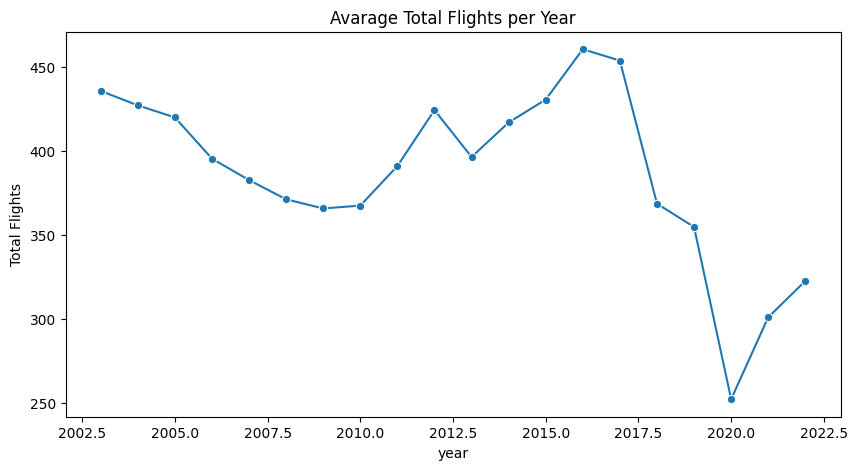

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average total flights per year
yearly_Total_Flights = airline.groupby("year")["total_flights"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_Total_Flights, x="year", y="total_flights", marker="o")
plt.title("Avarage Total Flights per Year")
plt.ylabel("Total Flights")
plt.show()


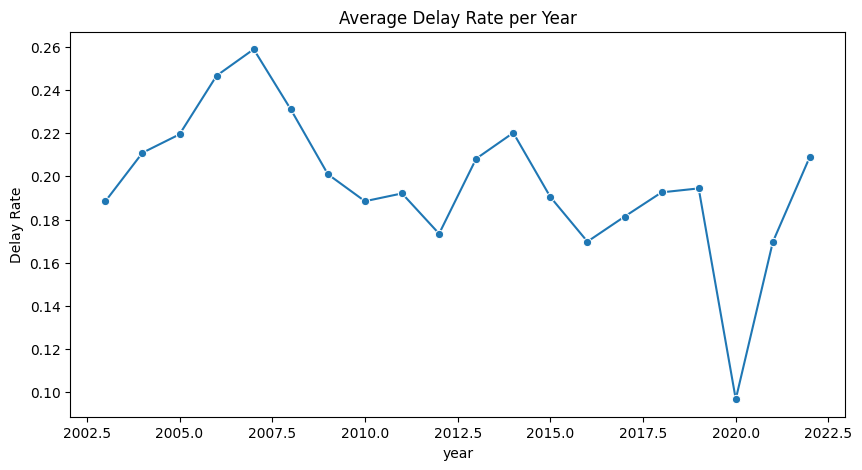

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average delay rate per year
yearly_delay = airline.groupby("year")["delay_rate"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_delay, x="year", y="delay_rate", marker="o")
plt.title("Average Delay Rate per Year")
plt.ylabel("Delay Rate")
plt.show()


C:\Users\Heka\AppData\Local\Temp\ipykernel_20308\39337154.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_delay, x="month", y="delay_rate", palette="viridis")


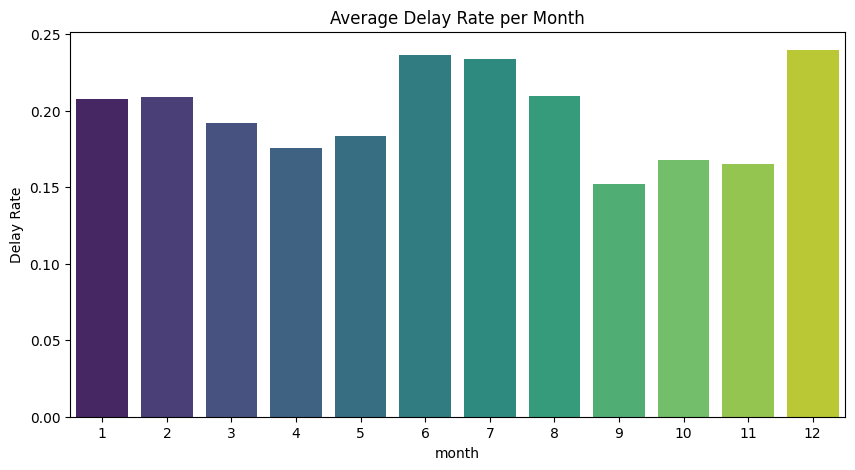

In [21]:
# Calculate average delay rate per month to identify seasonal patterns
monthly_delay = airline.groupby("month")["delay_rate"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=monthly_delay, x="month", y="delay_rate", palette="viridis")
plt.title("Average Delay Rate per Month")
plt.ylabel("Delay Rate")
plt.show()


C:\Users\Heka\AppData\Local\Temp\ipykernel_20308\421346810.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_carriers.index, y=top_carriers.values, palette="magma")


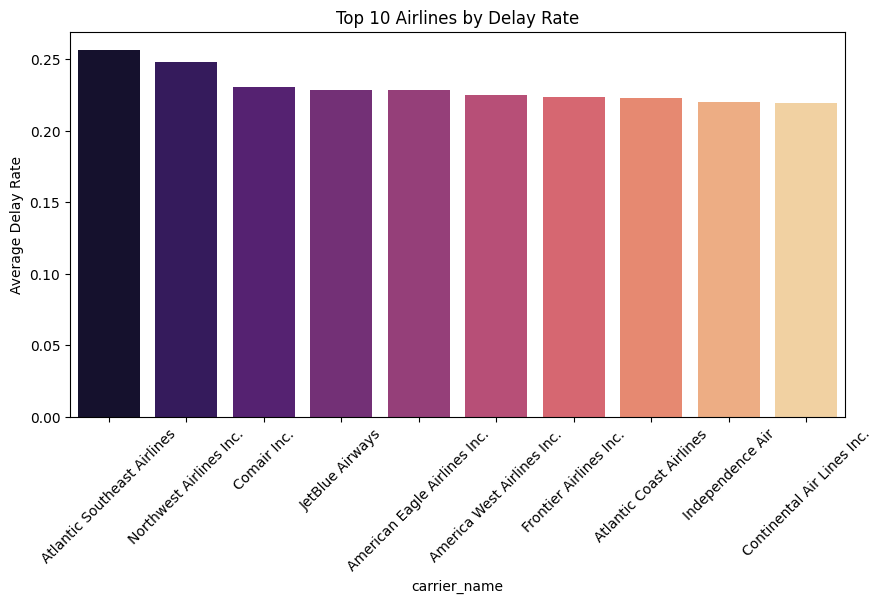

In [22]:
# Identify top 10 airlines with highest average delay rates
top_carriers = airline.groupby("carrier_name")["delay_rate"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_carriers.index, y=top_carriers.values, palette="magma")
plt.xticks(rotation=45)
plt.title("Top 10 Airlines by Delay Rate")
plt.ylabel("Average Delay Rate")
plt.show()



C:\Users\Heka\AppData\Local\Temp\ipykernel_20308\475681374.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_airports.head(10).index, y=top_airports.head(10).values, palette="coolwarm")


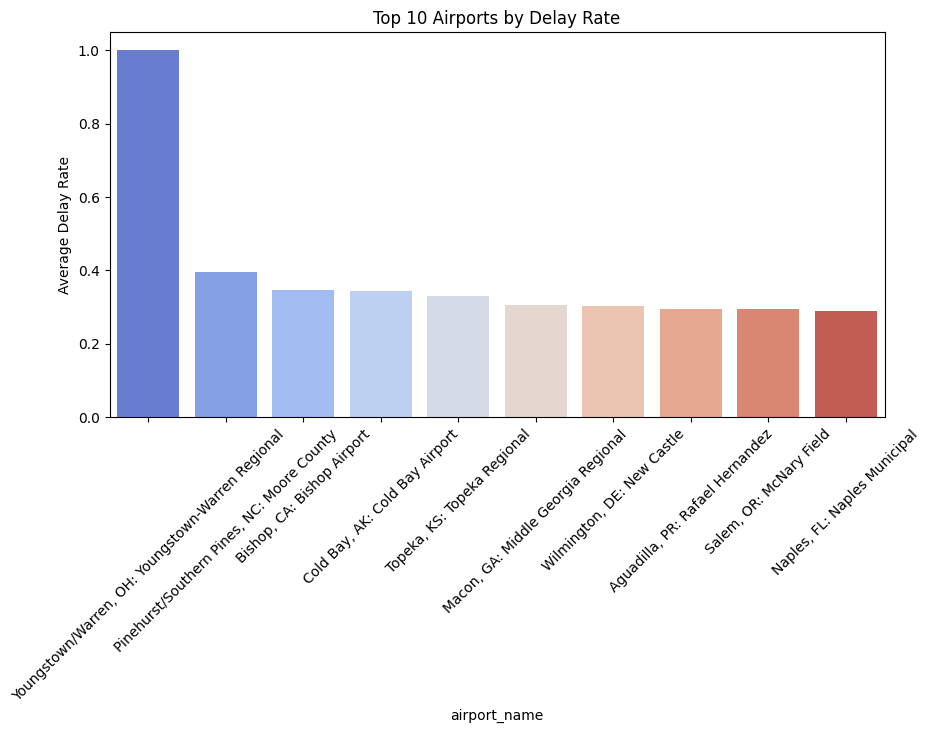

In [23]:
# Rank airports by average delay rate (delayed flights percentage)
top_airports = airline.groupby("airport_name")["delay_rate"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=top_airports.head(10).index, y=top_airports.head(10).values, palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Top 10 Airports by Delay Rate")
plt.ylabel("Average Delay Rate")
plt.show()


In [24]:
# Get top 10 carriers with highest delay rates
top_carriers = airline.groupby("carrier_name")["delay_rate"]\
                      .mean()\
                      .sort_values(ascending=False)\
                      .head(10).index

# Define delay cause columns
cause_cols = [
    "carrier_delay_ratio",
    "weather_delay_ratio",
    "nas_delay_ratio",
    "security_delay_ratio",
    "late_aircraft_ratio"
]

# Calculate average delay causes for each carrier
carrier_causes = airline[airline["carrier_name"].isin(top_carriers)]\
    .groupby("carrier_name")[cause_cols]\
    .mean()


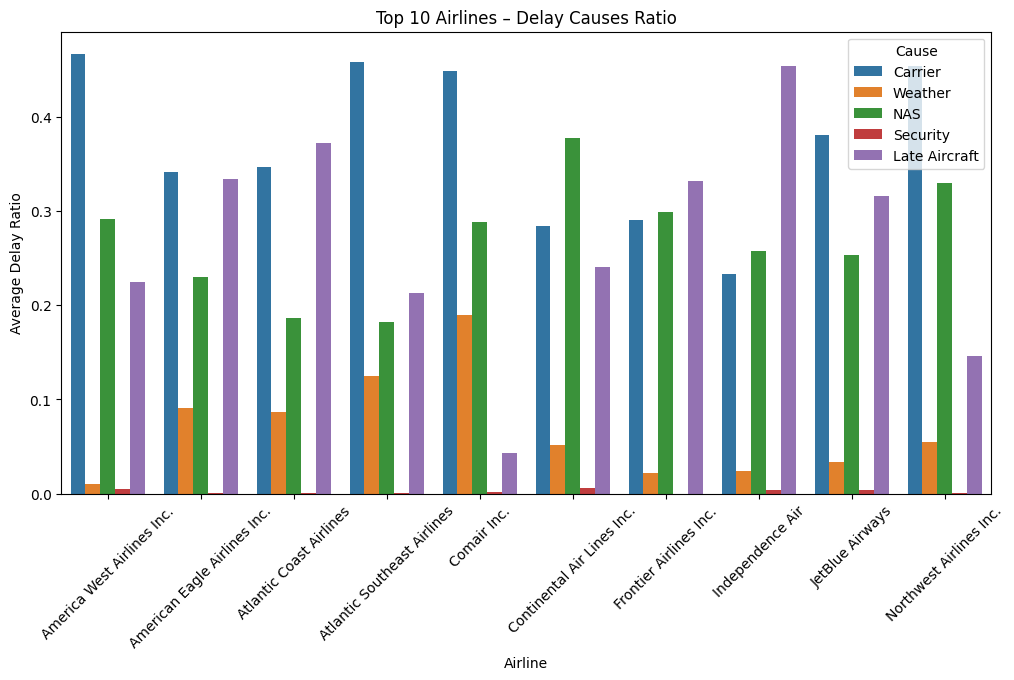

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

cause_cols = ["carrier_delay_ratio","weather_delay_ratio","nas_delay_ratio","security_delay_ratio","late_aircraft_ratio"]

# Transform DataFrame from wide to long format for visualization
carrier_long = carrier_causes[cause_cols].reset_index().melt(id_vars="carrier_name",
                                                             var_name="Cause",
                                                             value_name="Ratio")

# Rename columns to readable names
carrier_long["Cause"] = carrier_long["Cause"].replace({
    "carrier_delay_ratio":"Carrier",
    "weather_delay_ratio":"Weather",
    "nas_delay_ratio":"NAS",
    "security_delay_ratio":"Security",
    "late_aircraft_ratio":"Late Aircraft"
})

plt.figure(figsize=(12,6))
sns.barplot(data=carrier_long, x="carrier_name", y="Ratio", hue="Cause")
plt.title("Top 10 Airlines – Delay Causes Ratio")
plt.ylabel("Average Delay Ratio")
plt.xlabel("Airline")
plt.xticks(rotation=45)
plt.legend(title="Cause")
plt.show()


In [26]:
# Get top 10 airports with highest delay rates
top_airports = airline.groupby("airport_name")["delay_rate"].mean()\
                      .sort_values(ascending=False)\
                      .head(10).index

# Calculate average delay cause ratios for each airport
cause_cols = ["carrier_delay_ratio","weather_delay_ratio","nas_delay_ratio","security_delay_ratio","late_aircraft_ratio"]

airport_causes = airline[airline["airport_name"].isin(top_airports)]\
    .groupby("airport_name")[cause_cols]\
    .mean()\
    .reset_index()


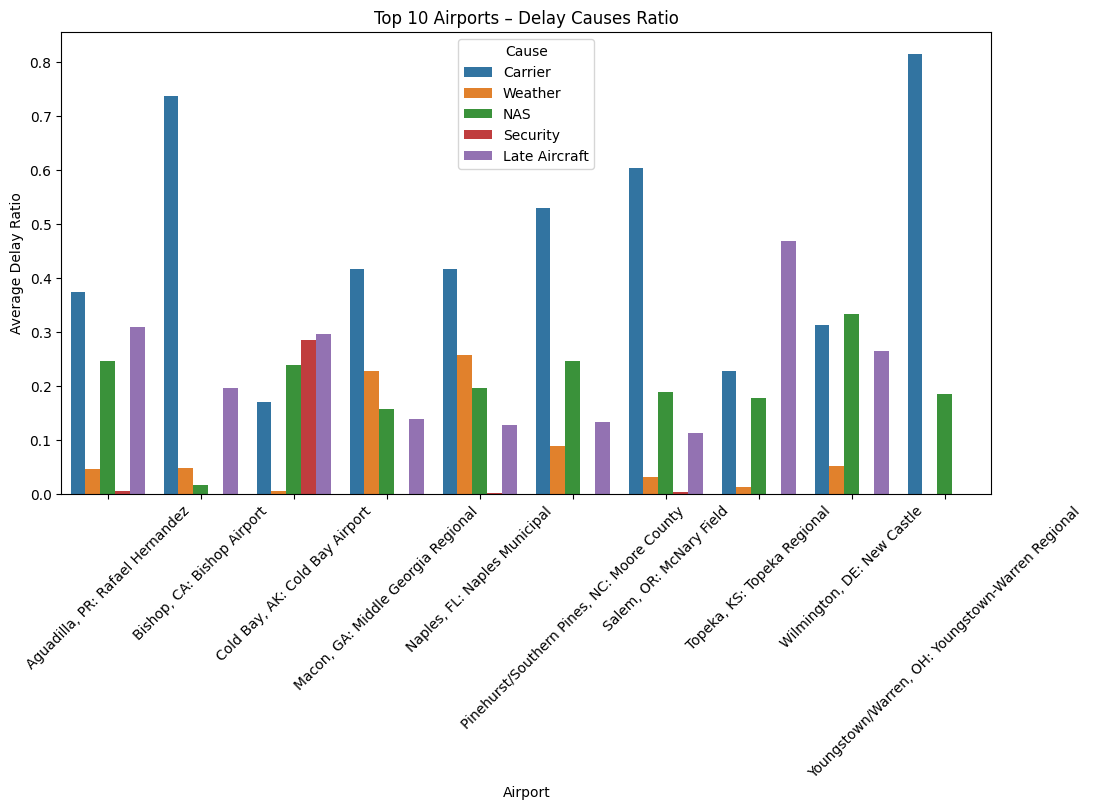

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

cause_cols = ["carrier_delay_ratio","weather_delay_ratio","nas_delay_ratio","security_delay_ratio","late_aircraft_ratio"]

airport_long = airport_causes[["airport_name"] + cause_cols].melt(
    id_vars="airport_name",
    var_name="Cause",
    value_name="Ratio"
)

# تغيير اسم الأعمدة لأسماء مفهومة
airport_long["Cause"] = airport_long["Cause"].replace({
    "carrier_delay_ratio":"Carrier",
    "weather_delay_ratio":"Weather",
    "nas_delay_ratio":"NAS",
    "security_delay_ratio":"Security",
    "late_aircraft_ratio":"Late Aircraft"
})

plt.figure(figsize=(12,6))
sns.barplot(data=airport_long, x="airport_name", y="Ratio", hue="Cause")
plt.title("Top 10 Airports – Delay Causes Ratio")
plt.ylabel("Average Delay Ratio")
plt.xlabel("Airport")
plt.xticks(rotation=45)
plt.legend(title="Cause")
plt.show()


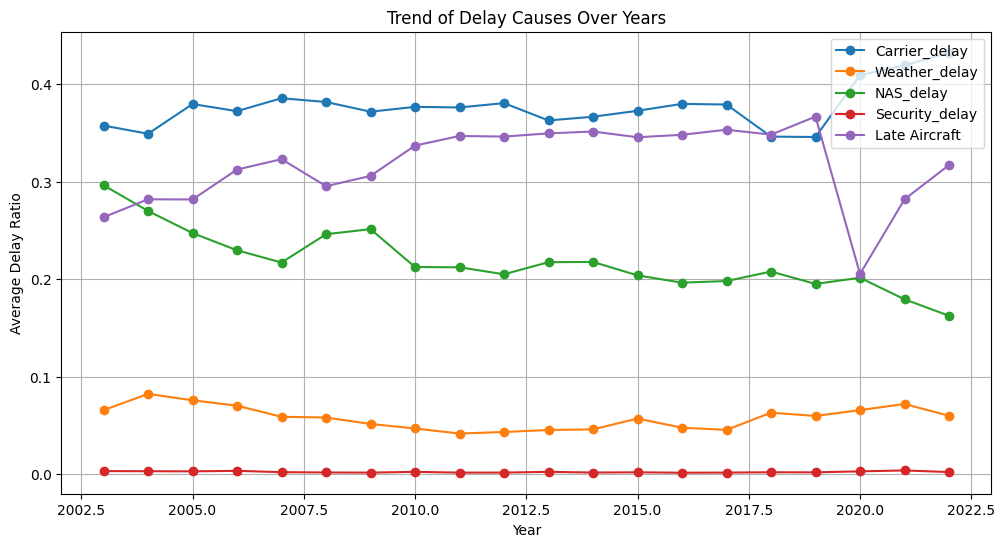

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define delay cause columns
cause_cols = ["carrier_delay_ratio","weather_delay_ratio","nas_delay_ratio","security_delay_ratio","late_aircraft_ratio"]

# Group by year and calculate average for each cause
yearly_trend = airline.groupby("year")[cause_cols].mean().reset_index()

plt.figure(figsize=(12,6))
for col in cause_cols:
    plt.plot(yearly_trend["year"], yearly_trend[col], marker='o', label=col.replace("_ratio","").replace("carrier","Carrier").replace("nas","NAS").replace("late_aircraft","Late Aircraft").replace("security","Security").replace("weather","Weather"))

plt.title("Trend of Delay Causes Over Years")
plt.xlabel("Year")
plt.ylabel("Average Delay Ratio")
plt.legend()
plt.grid(True)
plt.show()


In [29]:
# Display distribution of main delay causes
airline["main_delay_cause"].value_counts()

main_delay_cause
Carrier Delay                     67939
NAS Delay                         40585
Late Aircraft                     38704
Late Aircraft / Carrier Delay     33854
Carrier Delay / Late Aircraft     32350
Carrier Delay / NAS Delay         26397
NAS Delay / Carrier Delay         24691
Late Aircraft / NAS Delay         19100
NAS Delay / Late Aircraft         18320
No Delay                           8909
Carrier Delay / Weather Delay      2266
Weather Delay                      1181
NAS Delay / Weather Delay           850
Weather Delay / Carrier Delay       738
Late Aircraft / Weather Delay       539
Weather Delay / NAS Delay           431
Weather Delay / Late Aircraft       271
Security Delay                       49
Carrier Delay / Security Delay       41
NAS Delay / Security Delay           15
Late Aircraft / Security Delay       12
Security Delay / NAS Delay            6
Security Delay / Late Aircraft        5
Security Delay / Carrier Delay        4
Weather Delay / Securit

## 7. Model Preparation - Classification

Prepare data for classification model to predict delay causes.

In [30]:
# Drop categorical columns (carrier and airport names) for modeling
airline_modeling = airline.drop(columns=["carrier_name", "airport_name"], errors="ignore")


In [31]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
airline_modeling["season_encoded"] = label_encoder.fit_transform(airline_modeling["season"])
airline_modeling=airline_modeling.drop(columns=["season"])
airline_modeling.head()

,year,month,total_flights,delayed_flights_15m,carrier_delay_flights,weather_delay_flights,nas_delay_flights,security_delay_flights,late_aircraft_delay_flights,cancelled_flights,...,problem_rate,on_time_rate,delay_rate,main_delay_cause,carrier_delay_ratio,weather_delay_ratio,nas_delay_ratio,security_delay_ratio,late_aircraft_ratio,season_encoded
0,2022,5,136.0,7.0,5.95,0.00,0.05,0.0,1.00,0.0,...,0.051471,0.948529,0.051471,Carrier Delay,0.870588,0.000000,0.015686,0.0,0.113725,1
1,2022,5,91.0,16.0,7.38,0.00,2.54,0.0,6.09,0.0,...,0.175824,0.824176,0.175824,Carrier Delay / Late Aircraft,0.397059,0.000000,0.091629,0.0,0.511312,1
2,2022,5,19.0,2.0,0.13,0.00,1.00,0.0,0.88,1.0,...,0.157895,0.842105,0.105263,NAS Delay,0.028986,0.000000,0.768116,0.0,0.202899,1
3,2022,5,88.0,14.0,7.26,0.76,4.35,0.0,1.64,0.0,...,0.159091,0.840909,0.159091,Carrier Delay,0.617740,0.036959,0.131996,0.0,0.213305,1
4,2022,5,181.0,19.0,13.84,0.00,3.07,0.0,2.09,0.0,...,0.104972,0.895028,0.104972,Carrier Delay,0.819307,0.000000,0.107673,0.0,0.073020,1


In [32]:
import pandas as pd

X=airline_modeling.drop(columns=["main_delay_cause"])

y_class = pd.get_dummies(airline_modeling["main_delay_cause"], prefix="cause")



In [33]:
X_train, X_test, y_train, y_test = train_test_split(X,y_class, test_size=0.25, random_state=44, shuffle =True)

print('X_train shape is ' , X_train.shape)
print('X_test shape is ' , X_test.shape)
print('y_train shape is ' , y_train.shape)
print('y_test shape is ' , y_test.shape)

X_train shape is  (237945, 21)
X_test shape is  (79316, 21)
y_train shape is  (237945, 26)
y_test shape is  (79316, 26)


In [34]:
from sklearn.utils import class_weight

y_labels = y_class.idxmax(axis=1)  # اسم العمود لكل صف

classes = y_labels.unique()  # كل اسم فئة موجود
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_labels
)

# نعمل dict {اسم الفئة : weight}
class_weights_dict = dict(zip(classes, weights))
print(class_weights_dict)


{'cause_Carrier Delay': 0.17960738535813237, 'cause_Carrier Delay / Late Aircraft': 0.377197717274997, 'cause_NAS Delay': 0.3006614797054615, 'cause_NAS Delay / Late Aircraft': 0.6660669297950957, 'cause_Late Aircraft / Carrier Delay': 0.36044030701973634, 'cause_Late Aircraft': 0.31527351575666995, 'cause_Late Aircraft / NAS Delay': 0.6388662907772855, 'cause_No Delay': 1.3696650750753343, 'cause_NAS Delay / Carrier Delay': 0.49420218516245407, 'cause_Weather Delay / Late Aircraft': 45.027107578768096, 'cause_Carrier Delay / NAS Delay': 0.46226261142728925, 'cause_Weather Delay': 10.332215202240604, 'cause_Carrier Delay / Weather Delay': 5.384971824292212, 'cause_Late Aircraft / Weather Delay': 22.638861138861138, 'cause_NAS Delay / Weather Delay': 14.355701357466064, 'cause_Weather Delay / Carrier Delay': 16.534344381905356, 'cause_Weather Delay / NAS Delay': 28.31170801356416, 'cause_Security Delay': 249.02747252747253, 'cause_Carrier Delay / Security Delay': 297.6181988742964, 'cau

In [35]:
from tensorflow.keras import layers, models

from tensorflow import keras
KerasModel = keras.models.Sequential([

    keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(y_class.shape[1], activation='softmax')
])

c:\Users\Heka\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
MyOptimizer = tf.keras.optimizers.AdamW(
    learning_rate=0.001,
    weight_decay=5e-4,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07,
    amsgrad=False,
    clipnorm=None,
    clipvalue=None,
    global_clipnorm=None,
    use_ema=False,
    ema_momentum=0.99,
    ema_overwrite_frequency=None,
    name="AdamW")

In [37]:
KerasModel.compile(optimizer =MyOptimizer,loss='categorical_crossentropy',metrics=['accuracy']) # matrix

In [38]:
history = KerasModel.fit(X_train,y_train,
                         validation_data=(X_test,y_test),
                         epochs=100,
                         batch_size=5000,
                         verbose=1,
                          class_weight=class_weights_dict,

                         callbacks=[tf.keras.callbacks.EarlyStopping(
                                            patience=10,
                                            monitor='val_loss',#"val_loss",
                                            restore_best_weights=True)])


Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.1152 - loss: 225.7905 - val_accuracy: 0.1942 - val_loss: 9.7591
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2040 - loss: 7.8253 - val_accuracy: 0.2120 - val_loss: 7.2431
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1949 - loss: 4.8152 - val_accuracy: 0.2388 - val_loss: 2.8857
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2368 - loss: 2.7866 - val_accuracy: 0.2541 - val_loss: 2.6190
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2602 - loss: 2.5738 - val_accuracy: 0.2808 - val_loss: 2.4658
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2822 - loss: 2.4269 - val_accuracy: 0.2962 - val_loss: 2.3367
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2973 - loss: 2.2911 - val_accuracy: 0.3025 - val_loss: 2.1817
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3193 - loss: 2.1461 - val_accuracy: 

In [39]:
print(KerasModel.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 26)             │           858 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,032 (164.19 KB)

 Trainable params: 14,010 (54.73 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 28,022 (109.46 KB)

None


In [40]:
KerasModel.save('KerasModel.keras')


In [41]:
from tensorflow.keras.models import load_model
model = load_model('KerasModel.keras')


In [42]:
y_pred = model.predict(X_test)

2479/2479 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


In [43]:
print('Prediction Shape is {}'.format(y_pred.shape))


Prediction Shape is (79316, 26)


In [44]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Convert probabilities to predicted class labels
y_pred_labels = np.argmax(y_pred, axis=1)

# Convert one-hot encoded y_test to true class labels
y_test_labels = np.argmax(y_test.values, axis=1)

# Get the actual class names from the columns of y_class
class_names = y_class.columns.tolist()

# Map the numerical labels back to original class names for interpretation
y_pred_class_names = [class_names[label] for label in y_pred_labels]
y_test_class_names = [class_names[label] for label in y_test_labels]


# Calculate Accuracy
accuracy = accuracy_score(y_test_labels, y_pred_labels)
print(f"Accuracy: {accuracy:.4f}")

# Display Classification Report
print("\nClassification Report:")
print(classification_report(y_test_class_names, y_pred_class_names, labels=class_names, zero_division=0))

Accuracy: 0.8904

Classification Report:
                                      precision    recall  f1-score   support

                 cause_Carrier Delay       0.89      0.98      0.93     17051
 cause_Carrier Delay / Late Aircraft       0.91      0.85      0.88      8119
     cause_Carrier Delay / NAS Delay       0.85      0.81      0.83      6610
cause_Carrier Delay / Security Delay       0.00      0.00      0.00        10
 cause_Carrier Delay / Weather Delay       0.67      0.29      0.41       586
                 cause_Late Aircraft       0.95      0.92      0.93      9603
 cause_Late Aircraft / Carrier Delay       0.88      0.89      0.88      8480
     cause_Late Aircraft / NAS Delay       0.84      0.83      0.84      4674
cause_Late Aircraft / Security Delay       0.00      0.00      0.00         4
 cause_Late Aircraft / Weather Delay       0.47      0.24      0.32       121
                     cause_NAS Delay       0.92      0.95      0.93     10130
     cause_NAS Delay /

In [45]:

ModelLoss, ModelAccuracy = model.evaluate(X_test, y_test)
print('Model Loss is {}'.format(ModelLoss))
print('Model Accuracy is {}'.format(ModelAccuracy ))


2479/2479 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8897 - loss: 0.3267
Model Loss is 0.32327812910079956
Model Accuracy is 0.8904382586479187


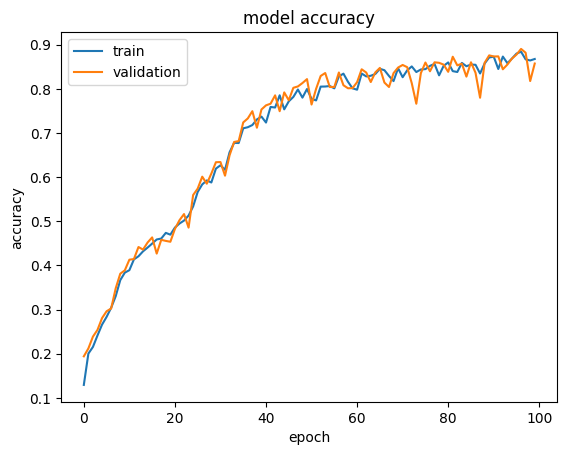

In [46]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()


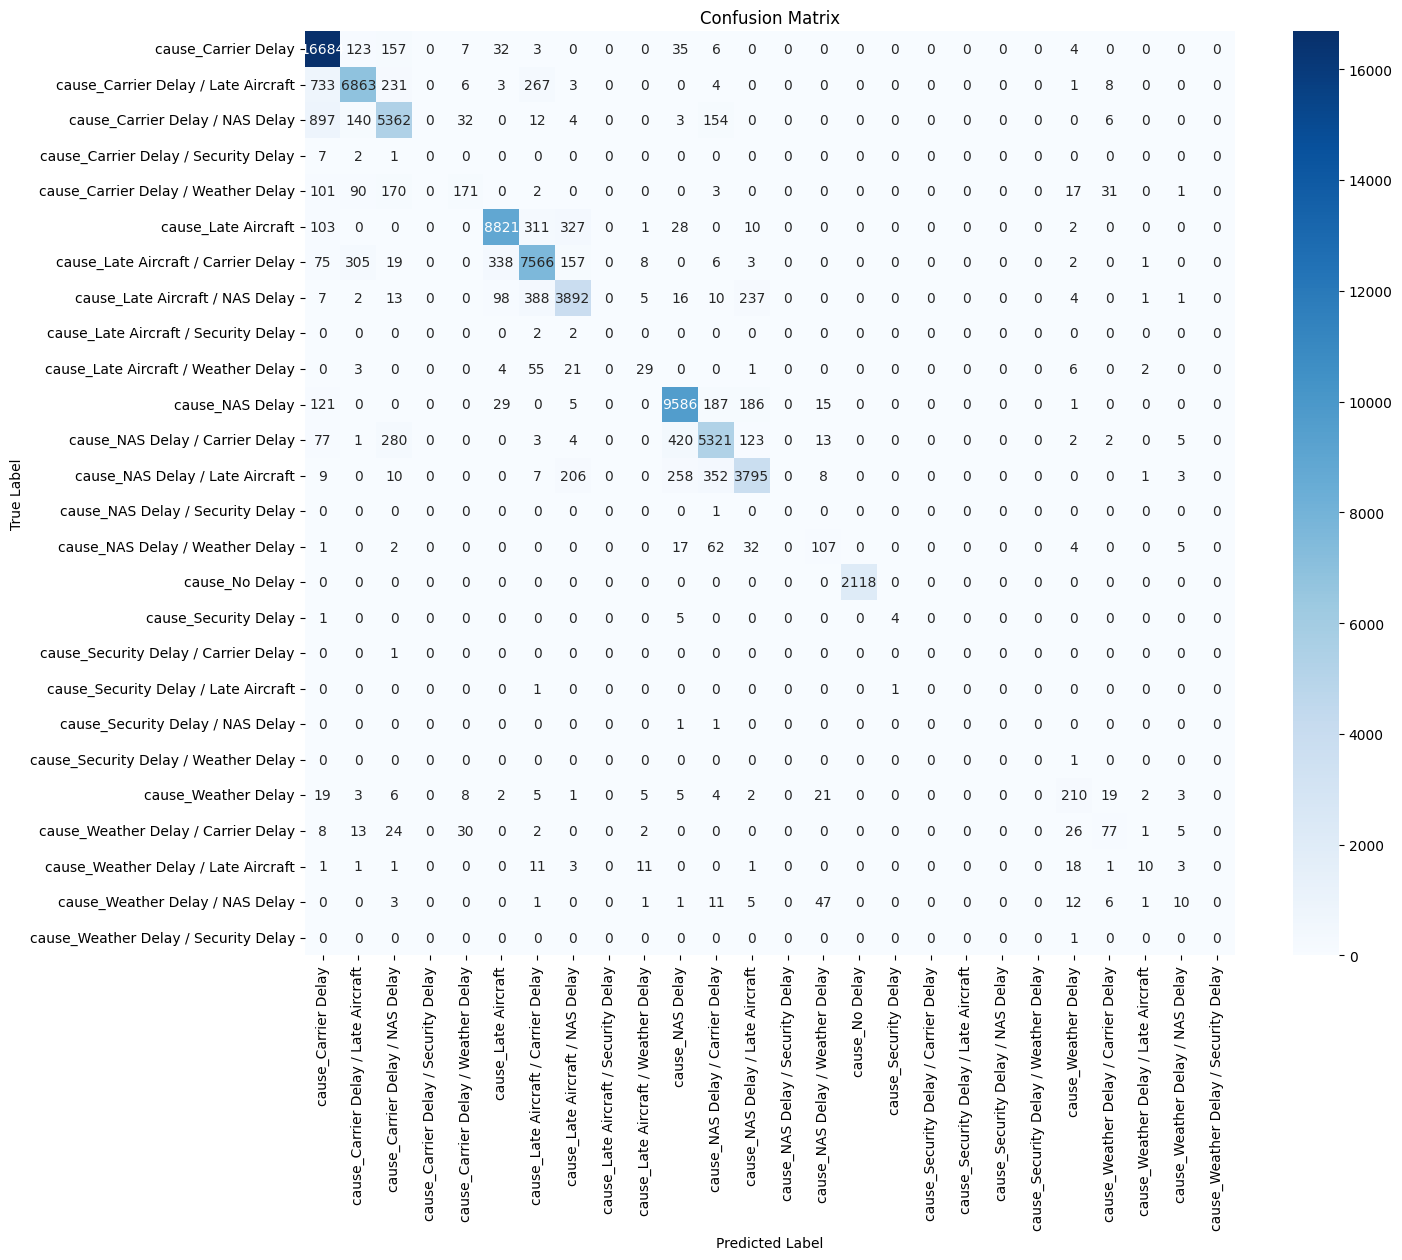

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Generate the confusion matrix
cm = confusion_matrix(y_test_labels, y_pred_labels)

# Plot the confusion matrix
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [48]:
import pandas as pd
airline_modeling_regression = airline.drop(columns=["carrier_name", "airport_name"], errors="ignore")



In [49]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
airline_modeling_regression["season_encoded"] = label_encoder.fit_transform(airline_modeling_regression["season"])
airline_modeling_regression["main_delay_cause_encoded"] = label_encoder.fit_transform(airline_modeling_regression["main_delay_cause"])

airline_modeling_regression = airline_modeling_regression.drop(columns=["season","main_delay_cause"])
airline_modeling_regression.head()

,year,month,total_flights,delayed_flights_15m,carrier_delay_flights,weather_delay_flights,nas_delay_flights,security_delay_flights,late_aircraft_delay_flights,cancelled_flights,...,problem_rate,on_time_rate,delay_rate,carrier_delay_ratio,weather_delay_ratio,nas_delay_ratio,security_delay_ratio,late_aircraft_ratio,season_encoded,main_delay_cause_encoded
0,2022,5,136.0,7.0,5.95,0.00,0.05,0.0,1.00,0.0,...,0.051471,0.948529,0.051471,0.870588,0.000000,0.015686,0.0,0.113725,1,0
1,2022,5,91.0,16.0,7.38,0.00,2.54,0.0,6.09,0.0,...,0.175824,0.824176,0.175824,0.397059,0.000000,0.091629,0.0,0.511312,1,1
2,2022,5,19.0,2.0,0.13,0.00,1.00,0.0,0.88,1.0,...,0.157895,0.842105,0.105263,0.028986,0.000000,0.768116,0.0,0.202899,1,10
3,2022,5,88.0,14.0,7.26,0.76,4.35,0.0,1.64,0.0,...,0.159091,0.840909,0.159091,0.617740,0.036959,0.131996,0.0,0.213305,1,0
4,2022,5,181.0,19.0,13.84,0.00,3.07,0.0,2.09,0.0,...,0.104972,0.895028,0.104972,0.819307,0.000000,0.107673,0.0,0.073020,1,0


In [50]:
X_reg=airline_modeling_regression.drop(columns=["delay_rate"])

Y= airline_modeling_regression[["delay_rate"]]


In [51]:
XX_train, XX_test, yy_train, yy_test = train_test_split(X_reg,Y, test_size=0.25, random_state=44, shuffle =True)

print('X_train shape is ' , XX_train.shape)
print('X_test shape is ' , XX_test.shape)
print('y_train shape is ' , yy_train.shape)
print('y_test shape is ' , yy_test.shape)

X_train shape is  (237945, 21)
X_test shape is  (79316, 21)
y_train shape is  (237945, 1)
y_test shape is  (79316, 1)


In [52]:
from tensorflow.keras import layers, models
from tensorflow import keras

KerasRegressionModel = keras.models.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(XX_train.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='linear') # Output layer for regression
])

c:\Users\Heka\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [53]:
import tensorflow as tf

MyOptimizer = tf.keras.optimizers.AdamW(
    learning_rate=0.001,
    weight_decay=5e-4,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07,
    amsgrad=False,
    clipnorm=None,
    clipvalue=None,
    global_clipnorm=None,
    use_ema=False,
    ema_momentum=0.99,
    ema_overwrite_frequency=None,
    name="AdamW")

In [54]:
KerasRegressionModel.compile(optimizer=MyOptimizer, loss='mean_squared_error', metrics=['mean_absolute_error'])

In [55]:
history_regression = KerasRegressionModel.fit(XX_train, yy_train,
                                                validation_data=(XX_test, yy_test),
                                                epochs=100,
                                                batch_size=5000,
                                                verbose=1,
                                                callbacks=[tf.keras.callbacks.EarlyStopping(
                                                    patience=10,
                                                    monitor='val_loss',
                                                    restore_best_weights=True)])

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 290965.2500 - mean_absolute_error: 166.9845 - val_loss: 9033.2910 - val_mean_absolute_error: 29.0264
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 11551.9639 - mean_absolute_error: 40.1821 - val_loss: 969.3791 - val_mean_absolute_error: 12.5427
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4083.8420 - mean_absolute_error: 24.4971 - val_loss: 148.4133 - val_mean_absolute_error: 9.1507
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1782.7494 - mean_absolute_error: 16.4420 - val_loss: 77.4849 - val_mean_absolute_error: 5.6117
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 895.8297 - mean_absolute_error: 11.5653 - val_loss: 54.6629 - val_mean_absolute_error: 3.3918
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 450.0686 - mean_absolute_error: 8.1786 - val_loss: 20.2127 - val_mean_absolute_error: 2.7065
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 190

In [56]:
# Make predictions on the test set
yy_pred = KerasRegressionModel.predict(XX_test)
print(f"Regression Predictions Shape: {yy_pred.shape}")

# Evaluate the model on the test set
regression_loss, regression_mae = KerasRegressionModel.evaluate(XX_test, yy_test, verbose=0)
print(f"Regression Test Loss (MSE): {regression_loss:.4f}")
print(f"Regression Test Mean Absolute Error (MAE): {regression_mae:.4f}")



2479/2479 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Regression Predictions Shape: (79316, 1)
Regression Test Loss (MSE): 0.0137
Regression Test Mean Absolute Error (MAE): 0.0684


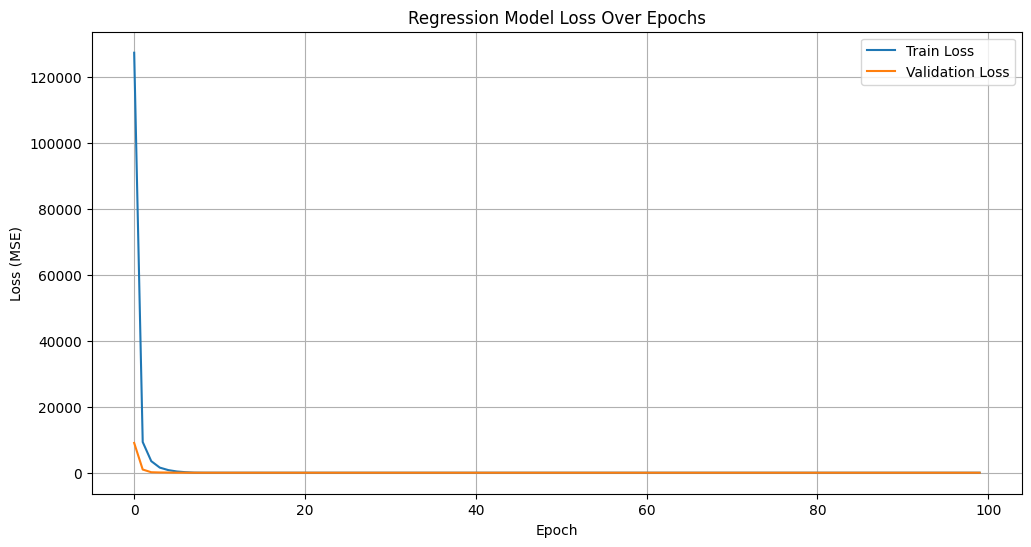

In [57]:
# Plotting the training history (loss)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(history_regression.history['loss'], label='Train Loss')
plt.plot(history_regression.history['val_loss'], label='Validation Loss')
plt.title('Regression Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()